# Validación de cinemática inversa

Compara la velocidad de plataforma **comandada** (`/robot/cmd_vel`) contra la velocidad
**recuperada por FK** sobre los encoders (`/robot/odometry · twist`).

Cadena validada:
$$[\hat{v}_x, \hat{v}_y, \hat{\omega}_z] \xrightarrow{\text{IK}} \hat{\omega}_i \xrightarrow{\text{sim}} \Delta\text{ticks}_i \xrightarrow{\text{FK}} [v_x', v_y', \omega_z']$$

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore, get_types_from_msg

BAG_PATH = Path("exp_inverse_k")

WHEEL_RADIUS = 0.05   # m
TICKS_PER_REV = 500
LX_PLUS_LY = 0.35    # m

In [ ]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

typestore.register(get_types_from_msg(
    "std_msgs/Header header\nint32[] ticks",
    "robmovil_msgs/msg/MultiEncoderTicks"
))

cmd_rows  = []  # (t_ns, vx, vy, wz)
odom_rows = []  # (t_ns, vx, vy, wz)
enc_rows  = []  # (t_ns, ticks[0..3])

with Reader(BAG_PATH) as reader:
    for connection, t_ns, rawdata in reader.messages():
        msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

        if connection.topic == "/robot/cmd_vel":
            cmd_rows.append((t_ns, msg.linear.x, msg.linear.y, msg.angular.z))

        elif connection.topic == "/robot/odometry":
            odom_rows.append((
                t_ns,
                msg.twist.twist.linear.x,
                msg.twist.twist.linear.y,
                msg.twist.twist.angular.z,
            ))

        elif connection.topic == "/robot/encoders":
            enc_rows.append((t_ns, *msg.ticks[:4]))

cmd  = pd.DataFrame(cmd_rows,  columns=["t_ns", "vx", "vy", "wz"])
odom = pd.DataFrame(odom_rows, columns=["t_ns", "vx", "vy", "wz"])
enc  = pd.DataFrame(enc_rows,  columns=["t_ns", "fl", "fr", "rl", "rr"])

t0 = min(cmd.t_ns.min(), odom.t_ns.min())
cmd["t"]  = (cmd.t_ns  - t0) * 1e-9
odom["t"] = (odom.t_ns - t0) * 1e-9
enc["t"]  = (enc.t_ns  - t0) * 1e-9

print(f"cmd_vel:  {len(cmd)} msgs")
print(f"odometry: {len(odom)} msgs")
print(f"encoders: {len(enc)} msgs")
print()
print("Comandos enviados:")
print(cmd[["t", "vx", "vy", "wz"]].to_string(index=False))

cmd_vel:  13 msgs
odometry: 193 msgs
encoders: 193 msgs

Comandos enviados:
        t   vx   vy  wz
 3.017354 -0.5 -0.5 0.0
 3.939529 -0.5 -0.5 0.0
 4.939455 -0.5 -0.5 0.0
 5.940816 -0.5 -0.5 0.0
 6.939858 -0.5 -0.5 0.0
 7.940142 -0.5 -0.5 0.0
 8.940395 -0.5 -0.5 0.0
 9.939687 -0.5 -0.5 0.0
10.939887 -0.5 -0.5 0.0
11.939995 -0.5 -0.5 0.0
12.939614 -0.5 -0.5 0.0
13.939639 -0.5 -0.5 0.0
14.939474 -0.5 -0.5 0.0


## Parte 1 — velocidad de plataforma: comandada vs. recuperada por FK

Para evitar el artefacto del ZOH, sólo se incluye la odometría **después del primer `cmd_vel`**.

In [7]:
first_cmd_ns = cmd.t_ns.iloc[0]

# solo odometría posterior al primer comando
odom_valid = odom[odom.t_ns >= first_cmd_ns].copy()

cmd_t = cmd.t_ns.values

def zoh(t_ns: np.ndarray, field: np.ndarray) -> np.ndarray:
    """Zero-order hold: último valor de field anterior a cada t_ns."""
    idx = np.searchsorted(cmd_t, t_ns, side="right") - 1
    idx = np.clip(idx, 0, len(field) - 1)
    return field[idx]

odom_valid["cmd_vx"] = zoh(odom_valid.t_ns.values, cmd.vx.values)
odom_valid["cmd_vy"] = zoh(odom_valid.t_ns.values, cmd.vy.values)
odom_valid["cmd_wz"] = zoh(odom_valid.t_ns.values, cmd.wz.values)

odom_valid["e_vx"] = odom_valid.cmd_vx - odom_valid.vx
odom_valid["e_vy"] = odom_valid.cmd_vy - odom_valid.vy
odom_valid["e_wz"] = odom_valid.cmd_wz - odom_valid.wz

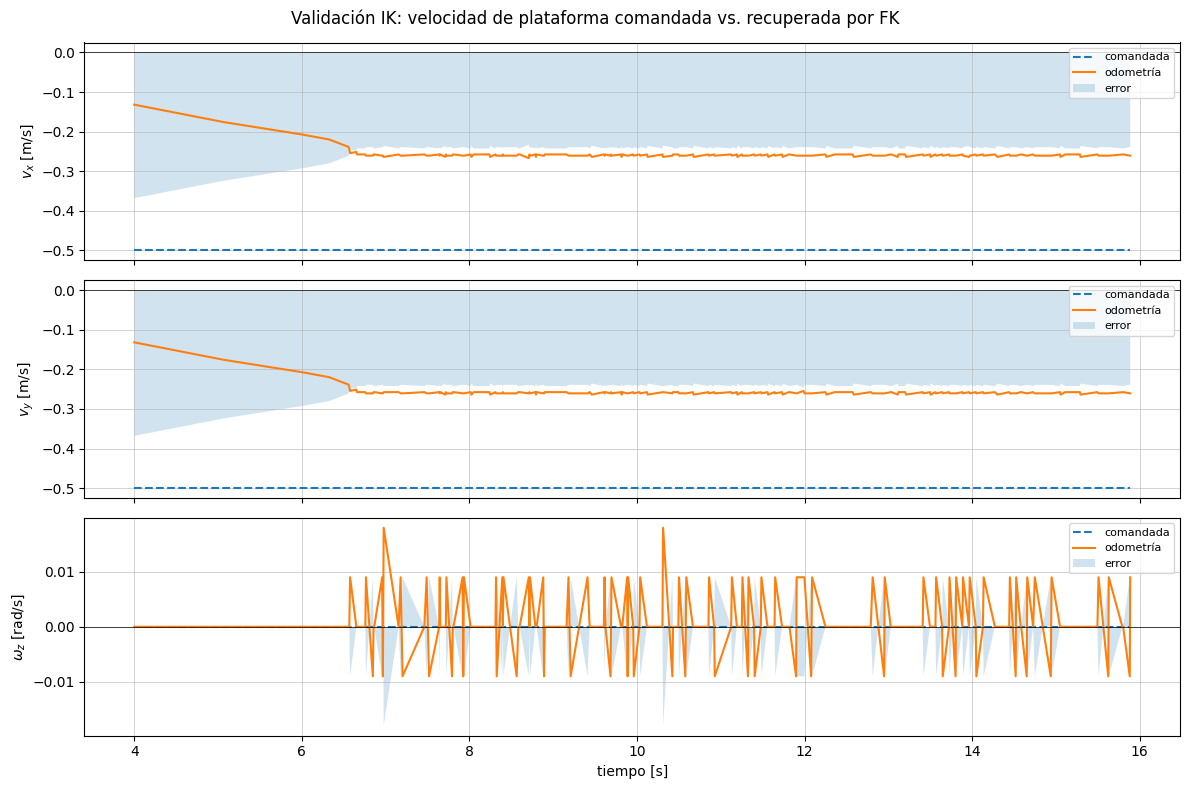

RMSE:
  vx: 0.2424
  vy: 0.2426
  wz: 0.0061


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
specs = [
    ("vx", "cmd_vx", "e_vx", "$v_x$ [m/s]"),
    ("vy", "cmd_vy", "e_vy", "$v_y$ [m/s]"),
    ("wz", "cmd_wz", "e_wz", "$\\omega_z$ [rad/s]"),
]
for ax, (actual_col, cmd_col, err_col, ylabel) in zip(axes, specs):
    ax.plot(odom_valid.t, odom_valid[cmd_col],    label="comandada",  linewidth=1.5, linestyle="--")
    ax.plot(odom_valid.t, odom_valid[actual_col], label="odometría",  linewidth=1.5)
    ax.fill_between(odom_valid.t, odom_valid[err_col], alpha=0.2, label="error")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linewidth=0.4)

axes[-1].set_xlabel("tiempo [s]")
fig.suptitle("Validación IK: velocidad de plataforma comandada vs. recuperada por FK")
fig.tight_layout()
plt.savefig("../docs/assets/cinematica_inversa_plataforma.png", dpi=150)
plt.show()

print("RMSE:")
for col, label in [("e_vx", "vx"), ("e_vy", "vy"), ("e_wz", "wz")]:
    rmse = np.sqrt((odom_valid[col] ** 2).mean())
    print(f"  {label}: {rmse:.4f}")

## Parte 2 — velocidad de rueda: comandada vs. real (encoders)

Aísla si el error viene del simulador (el joint no alcanza la velocidad pedida)
o de la IK/FK.

$$\omega_i^\text{real} = \frac{\Delta\text{ticks}_i}{500} \cdot \frac{2\pi}{\Delta t}$$

Orden de ruedas en `ticks[]`: `fl=0, fr=1, rl=2, rr=3`.

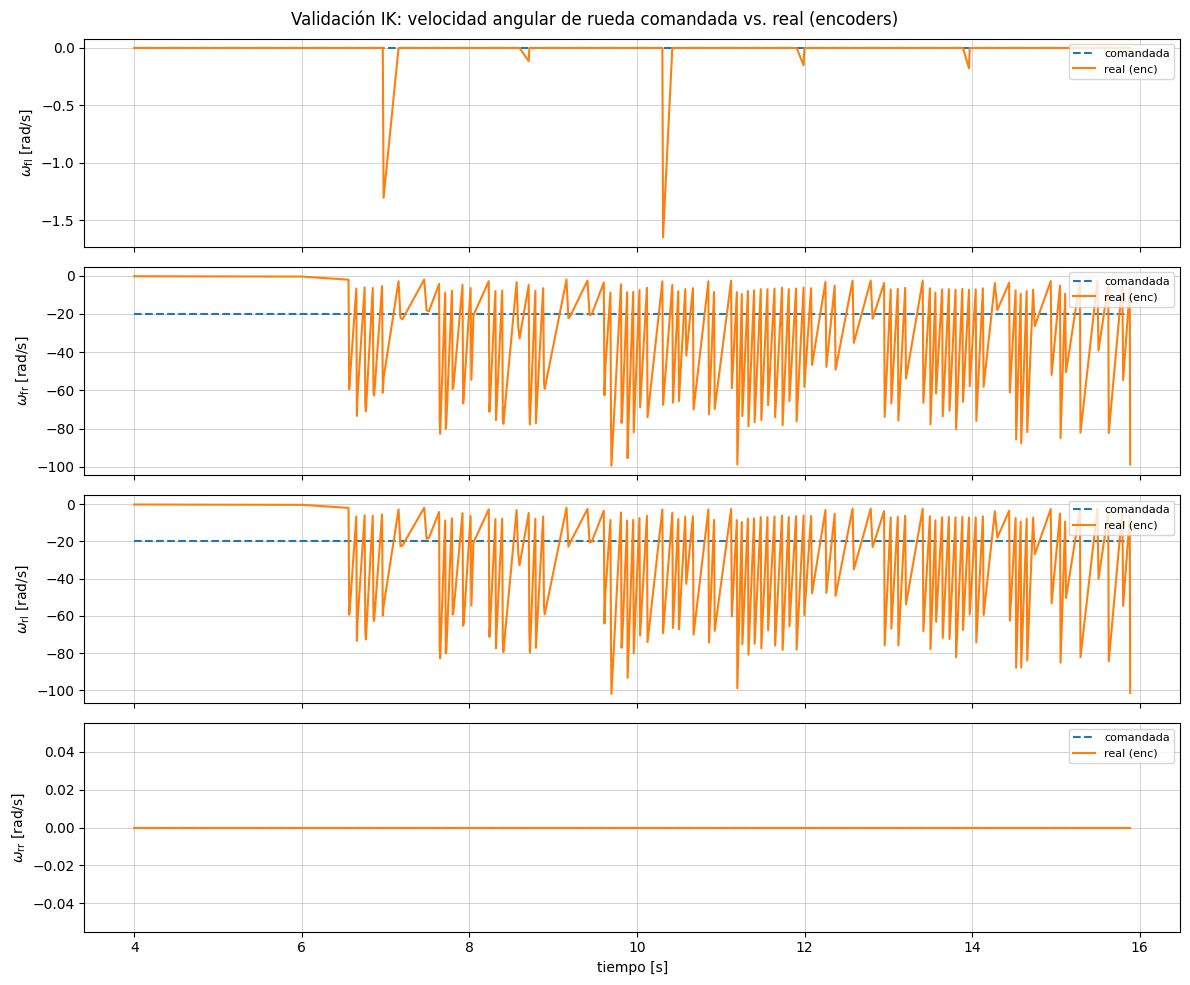

RMSE por rueda:
  fl: 0.1541 rad/s
  fr: 36.3221 rad/s
  rl: 36.7050 rad/s
  rr: 0.0000 rad/s


In [9]:
if len(enc) == 0:
    print("No hay datos de encoders en el bag — grabá con /robot/encoders incluido.")
else:
    dt_enc = enc.t_ns.diff().iloc[1:].values * 1e-9
    for wheel in ["fl", "fr", "rl", "rr"]:
        delta_ticks = enc[wheel].diff().iloc[1:].values
        enc.loc[enc.index[1:], f"w_{wheel}"] = (delta_ticks / TICKS_PER_REV) * (2 * np.pi) / dt_enc

    enc_valid = enc[enc.t_ns >= first_cmd_ns].dropna().copy()

    # IK: fl=(vx-vy-(lx+ly)*wz)/r, fr=(vx+vy+(lx+ly)*wz)/r
    #     rl=(vx+vy-(lx+ly)*wz)/r, rr=(vx-vy+(lx+ly)*wz)/r
    def ik(vx, vy, wz):
        k = 1.0 / WHEEL_RADIUS
        return {
            "fl": k * (vx - vy - LX_PLUS_LY * wz),
            "fr": k * (vx + vy + LX_PLUS_LY * wz),
            "rl": k * (vx + vy - LX_PLUS_LY * wz),
            "rr": k * (vx - vy + LX_PLUS_LY * wz),
        }

    cmd_vx = zoh(enc_valid.t_ns.values, cmd.vx.values)
    cmd_vy = zoh(enc_valid.t_ns.values, cmd.vy.values)
    cmd_wz = zoh(enc_valid.t_ns.values, cmd.wz.values)
    ik_out = ik(cmd_vx, cmd_vy, cmd_wz)
    for wheel in ["fl", "fr", "rl", "rr"]:
        enc_valid[f"w_cmd_{wheel}"] = ik_out[wheel]

    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    for ax, wheel in zip(axes, ["fl", "fr", "rl", "rr"]):
        ax.plot(enc_valid.t, enc_valid[f"w_cmd_{wheel}"], label="comandada", linestyle="--", linewidth=1.5)
        ax.plot(enc_valid.t, enc_valid[f"w_{wheel}"],     label="real (enc)", linewidth=1.5)
        ax.set_ylabel(f"$\\omega_{{\\text{{{wheel}}}}}$ [rad/s]")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, linewidth=0.4)

    axes[-1].set_xlabel("tiempo [s]")
    fig.suptitle("Validación IK: velocidad angular de rueda comandada vs. real (encoders)")
    fig.tight_layout()
    plt.savefig("../docs/assets/cinematica_inversa_ruedas.png", dpi=150)
    plt.show()

    print("RMSE por rueda:")
    for wheel in ["fl", "fr", "rl", "rr"]:
        e = enc_valid[f"w_cmd_{wheel}"] - enc_valid[f"w_{wheel}"]
        print(f"  {wheel}: {np.sqrt((e**2).mean()):.4f} rad/s")